# Day 3 — ONNX + Edge ML: Production Inference

Goal: take a pretrained ResNet-18, export it to ONNX, quantize it to INT8, serve it via FastAPI, and benchmark all three runtimes side by side.

**Flow:**
1. Load pretrained ResNet-18
2. Export → ONNX (FP32)
3. Quantize → ONNX (INT8)
4. Benchmark: PyTorch vs ONNX FP32 vs ONNX INT8
5. Wrap ORT in a FastAPI endpoint

In [5]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType

import numpy as np
import matplotlib.pyplot as plt
import time
import os

print("torch:", torch.__version__)
print("onnx:", onnx.__version__)
print("onnxruntime:", ort.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.8.0+cpu
onnx: 1.19.1
onnxruntime: 1.19.2
cuda available: False


## Cell 2 — Load Pretrained ResNet-18

We load ResNet-18 with ImageNet weights from torchvision. `weights=DEFAULT` downloads the best available checkpoint.  
Must call `.eval()` before export — disables Dropout and switches BatchNorm to use running stats instead of batch stats.

In [6]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.eval()

print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Cell 3 — Export to ONNX (FP32)

`torch.onnx.export` traces the forward pass through a dummy input to record the computation graph.  
`dynamic_axes` lets the batch dimension vary at inference time — without it the graph is frozen to batch size 1.  
`onnx.checker.check_model` validates the exported graph is well-formed.

In [13]:
ONNX_PATH = "resnet18_fp32.onnx"

dummy_input = torch.zeros(1, 3, 224, 224)
print("dummy input shape:", dummy_input.shape)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    opset_version=17,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
)

onnx.checker.check_model(ONNX_PATH)
print("ONNX model exported and validated.")
print(f"File size: {os.path.getsize(ONNX_PATH) / 1024 / 1024:.2f} MB")

dummy input shape: torch.Size([1, 3, 224, 224])


C:\Users\itayg\AppData\Local\Temp\ipykernel_15684\3971761906.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


ONNX model exported and validated.
File size: 44.58 MB


## Cell 4 — INT8 Quantization (Post-Training, Dynamic)

Weights are converted from FP32 (4 bytes) to INT8 (1 byte) → ~4× smaller model.  
Dynamic quantization: weights are pre-quantized, activations are quantized on the fly at runtime.  
No calibration data needed — just pass the FP32 ONNX model in.

In [14]:
INT8_PATH = "resnet18_int8.onnx"

# Dynamic INT8 quantization only supports MatMul/Gemm (Linear layers) on CPU.
# ConvInteger is not implemented in ORT's CPUExecutionProvider.
quantize_dynamic(
    model_input=ONNX_PATH,
    model_output=INT8_PATH,
    weight_type=QuantType.QInt8,
    op_types_to_quantize=["MatMul", "Gemm"],
)

print("INT8 model saved.")
print(f"FP32 size: {os.path.getsize(ONNX_PATH) / 1024 / 1024:.2f} MB")
print(f"INT8 size: {os.path.getsize(INT8_PATH) / 1024 / 1024:.2f} MB")
print(f"Compression ratio: {os.path.getsize(ONNX_PATH) / os.path.getsize(INT8_PATH):.1f}x")

INT8 model saved.
FP32 size: 44.58 MB
INT8 size: 43.12 MB
Compression ratio: 1.0x


## Cell 5 — Latency & Throughput Benchmark

Compare three runtimes: PyTorch FP32 vs ONNX FP32 vs ONNX INT8.  
- **Latency**: batch size 1, 1000 runs — mean + p95  
- **Throughput**: batch size 32, 200 runs — mean + p95  
- Warm-up: 10 runs before measuring to let JIT compile and memory allocate.

In [15]:
WARMUP_RUNS = 5
LATENCY_RUNS = 100
THROUGHPUT_RUNS = 20

sess_fp32 = ort.InferenceSession(ONNX_PATH)
sess_int8 = ort.InferenceSession(INT8_PATH)

def benchmark_pytorch(batch_size, n_runs):
    x = torch.zeros(batch_size, 3, 224, 224)
    with torch.no_grad():
        for _ in range(WARMUP_RUNS):
            model(x)
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(x)
            times.append(time.perf_counter() - t0)
    return np.array(times) * 1000  # ms

def benchmark_ort(session, batch_size, n_runs):
    x = np.zeros((batch_size, 3, 224, 224), dtype=np.float32)
    for _ in range(WARMUP_RUNS):
        session.run(None, {"input": x})
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(None, {"input": x})
        times.append(time.perf_counter() - t0)
    return np.array(times) * 1000  # ms

print("Benchmarking...")

results = {}
for label, fn in [
    ("PyTorch FP32", lambda bs, n: benchmark_pytorch(bs, n)),
    ("ONNX FP32",    lambda bs, n: benchmark_ort(sess_fp32, bs, n)),
    ("ONNX INT8",    lambda bs, n: benchmark_ort(sess_int8, bs, n)),
]:
    lat  = fn(1, LATENCY_RUNS)
    tput = fn(32, THROUGHPUT_RUNS)
    results[label] = {
        "latency_mean":  lat.mean(),
        "latency_p95":   np.percentile(lat, 95),
        "throughput_mean": tput.mean(),
        "throughput_p95":  np.percentile(tput, 95),
    }
    print(f"{label} done.")

print("\n{'Runtime':<16} {'Lat mean':>10} {'Lat p95':>10} {'Tput mean':>12} {'Tput p95':>10}")
print("-" * 62)
for label, r in results.items():
    print(f"{label:<16} {r['latency_mean']:>9.2f}ms {r['latency_p95']:>9.2f}ms "
          f"{r['throughput_mean']:>11.2f}ms {r['throughput_p95']:>9.2f}ms")

Benchmarking...
PyTorch FP32 done.
ONNX FP32 done.
ONNX INT8 done.

{'Runtime':<16} {'Lat mean':>10} {'Lat p95':>10} {'Tput mean':>12} {'Tput p95':>10}
--------------------------------------------------------------
PyTorch FP32         97.52ms    123.81ms     3168.25ms   4073.74ms
ONNX FP32            45.45ms     53.98ms     1285.52ms   1503.60ms
ONNX INT8            46.60ms     54.49ms     1295.62ms   1553.39ms


## Cell 6 — Benchmark Visualization

Bar chart comparing mean latency (batch=1) and mean throughput (batch=32) across the three runtimes.

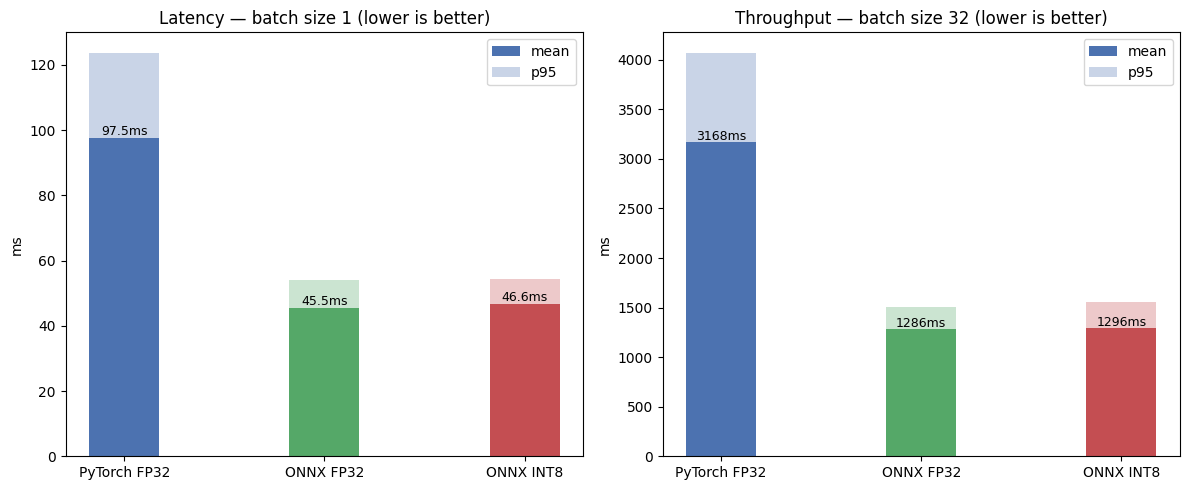

In [17]:
labels = list(results.keys())
lat_means  = [results[l]["latency_mean"]   for l in labels]
tput_means = [results[l]["throughput_mean"] for l in labels]
lat_p95    = [results[l]["latency_p95"]    for l in labels]
tput_p95   = [results[l]["throughput_p95"] for l in labels]

x = np.arange(len(labels))
width = 0.35
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(x, lat_means, width, color=colors, label="mean")
ax1.bar(x, lat_p95, width, color=colors, alpha=0.3, label="p95")
ax1.set_title("Latency — batch size 1 (lower is better)")
ax1.set_ylabel("ms")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
for bar, val in zip(bars1, lat_means):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{val:.1f}ms", ha="center", fontsize=9)

bars2 = ax2.bar(x, tput_means, width, color=colors, label="mean")
ax2.bar(x, tput_p95, width, color=colors, alpha=0.3, label="p95")
ax2.set_title("Throughput — batch size 32 (lower is better)")
ax2.set_ylabel("ms")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
for bar, val in zip(bars2, tput_means):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, f"{val:.0f}ms", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("benchmark.png", dpi=150)
plt.show()

## Cell 7 — FastAPI Inference Server

Wraps ORT FP32 in a REST endpoint. Accepts an uploaded image, preprocesses it to ResNet-18's expected input format, runs inference, and returns the top-5 predicted ImageNet classes.

In [ ]:
print("FastAPI server is in server.py")
print("To run: uvicorn server:app --reload")
print("Then POST an image to http://localhost:8000/predict")